In [ ]:
# remember to set kernel to 3.11 conda env for model
# actually other python versions work too, just got to be atleast 3.9 and below 3.14

# just putting this here just in case, read setup.txt to see how to run this project.

# PipeLine
The current pipeline has been adjusted from original.
Data is now being collected via scraper from youtube, tiktok, and any sources with "Free" apis.

These videos will then be parallel processed into tensors (WIP).

Tensors will be used for model training for a moe(mixture of experts) multimodal structure. (look at other section for architecture details)

Model weights will then be loaded and ran through a main script which will output a final score and plot.

For MVP we currently have a barebones docker and celery(task queue library) setup. (final webpage will be different)

# Data Preprocessing
The data we will be using will be mp4s, avis, and movs that are processed into tensors. But stick to mp4s

Currently the script making tensors is more of a proof of concept with very small parameters, (256 x 256 pixels) and 32 frames per video.

First define what how a tensor is made, take [3, 256, 256], this is a 3d tensor where 3 is the # of channels here its is rgb, the last are image parameters.\
These are then stacked into 4d tensors during training so that the first number is the batch size.\
Some models use a 5d tensor like the lstm which uses [batchsize, sequence length, channels, parameter, parameter].

What is in each tensor: 
single clean image for the router to base its confidence in (rgb image 256x256)\
A batch of rgb images for the artifact model\
A batch of diff images for the temporal model\
prnu image for the noise model\
fft image for the frequency model\
audio spectrogram for the audio model (channel, frequency, time)




# Model Architecture 

Before I go into specifics of each model, first a brief overview on the overarching model's output and input.

The moe acts as a top-level distributor of trust and final arbitrator, with each "expert model" will output their confidence levels of an input.\
It uses a pretrained resnet18 that connects to a fc layer (fully connected) that goes into a softmax function for the output (0,1)\
This is coupled with a context frame so that the model can learn/contextualize videos to determine which models are best suited
```
class InvestigatorRouter(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(4),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(4),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten()
        )
        self.fc = nn.Linear(64, 5)

    def forward(self, x):
        features = self.cnn(x)
        logits = self.fc(features)
        return F.softmax(logits, dim=1)
```

Now we can move onto the individual models

The temporal model works off a batch of grayscale diff frames to output a confidence score.\
Data is fed through a 2d CNN encoder that goes through a LSTM classifier which uses a sliding window of diff_seq frames.
```
# 1. The Eye (Spatial CNN)
# We strip the final layers to get raw features
self.cnn_encoder = nn.Sequential(
    nn.Conv2d(1, 16, 3, 1, 1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(16, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
    nn.Flatten()
)
# Wrap it
self.time_distributed = TimeDistributed(self.cnn_encoder)
# Feature size calculation: 256 -> 128 -> 64 -> 32
# Final shape: 64 channels * 32 * 32
self.feature_size = 64 * 32 * 32 
# 2. The Memory (LSTM)
self.lstm = nn.LSTM(
    input_size=self.feature_size,
    hidden_size=256,
    num_layers=2,
    batch_first=True,
    dropout=0.2
)
# 3. The Verdict
self.fc = nn.Linear(256, 1)
```

The artifact/area detection model uses a batch of rgb frames to detect unusual blurring, warping, or mismatches to usual frames.\
The data is inputted into a U-net with skip connections. This model is trained supervised where the output is a mask of the detected anomaly\
This is then translated into a heatmap of the entire batch that is interpreted through the maximum intensity
```
def __init__(self):
    super().__init__()
    self.enc1 = self.conv_block(3, 32); self.pool1 = nn.MaxPool2d(2)
    self.enc2 = self.conv_block(32, 64); self.pool2 = nn.MaxPool2d(2)
    self.enc3 = self.conv_block(64, 128)
    self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
    self.dec2 = self.conv_block(128 + 64, 64)
    self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
    self.dec1 = self.conv_block(64 + 32, 32)
    self.final = nn.Conv2d(32, 1, kernel_size=1)
def conv_block(self, in_c, out_c):
    return nn.Sequential(nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(), nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU())
def forward(self, x):
    e1 = self.enc1(x); p1 = self.pool1(e1); e2 = self.enc2(p1); p2 = self.pool2(e2); e3 = self.enc3(p2)
    d2 = self.up2(e3); d2 = torch.cat([d2, e2], dim=1); d2 = self.dec2(d2)
    d1 = self.up1(d2); d1 = torch.cat([d1, e1], dim=1); d1 = self.dec1(d1)
    return self.final(d1)
```

The noise or prnu model is a shallow 3 layer CNN that takes in an average grayscale image of a prnu stack from data\
This is then fed into the model and into a probabilistic function that outputs a confidence scale.\
There are some nitpicks with using any kind of noise/prnu as an indicator of ai-generation as cameras have fixed static noise patterns from lens imperfections\
While ai videos have synthetic (uniform or almost guassian noise patterns) noise throughout the video.\
This becomes iffy when you try to run videos that are edited, compressed, or transformed when posted online.\
```
def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Conv2d(1, 8, 3, padding=1), nn.BatchNorm2d(8), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.3),
        nn.Conv2d(8, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2), nn.Dropout(0.4),
        nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten()
    )
def forward(self, x): return self.net(x)
```

The frequency (fft) model takes a general fourier spectrum across frames in a video and feeds it into a simple CNN that outputs a confidence score.\
I don't have much confidence that this model will be very accurate since its highly dependent on the ai-generated video to have strong or any spectral artifacts\
which mainly come frame convulational upsampling during generation (feel free to research and look deeper into this concept).\
```
def __init__(self):
    super().__init__()
    # Takes 1-channel FFT Spectrum [B, 1, 256, 256]
    self.net = nn.Sequential(
        nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(64 * 32 * 32, 256), nn.ReLU(), nn.Linear(256, 1)
    )
def forward(self, x): return self.net(x)
```
The audio model uses an audio spectrogram as input into a resnet18 that outputs a confidence level.\
I personally don't really understand how this functions yet, the librosa library was new to me so I had mainly copied of documentation examples and ai.\
But in essence the spectrogram should have some kind of pattern or artifacts that allow for differentiation of tts from real humans or some kind of background chatter\
```
def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d((1,1)),
        nn.Flatten(),
        nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1)
    )
def forward(self, x): return self.net(x)
```

# research

Read this paper https://arxiv.org/pdf/2510.08073 if you haven't (its long so skim it or run it through ai), the ideas presented on temporal spatial analysis is pretty interesting. Hard to really implement without knowing the math behind the algorithm in-depth, so what I have now is a really dumbed down version of what they use. Maybe in the future when we need more performance or have the time we can pivot the specific temporal model to mirror their normalized spectral gradient approach using a maximum mean discrepency.

Also look at any videos on machinelearning on youtube or read any websites or papers online.\
Would recommned watching 3blue1browns series on DeepLearning if you haven't: https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi




# Accuracy Documentation

The typical way to train a model is to seperate inputted data into a validation set and a training set, and let the model run on the validation set after each training epoch to determine its accuracy. But there are also more parameters that show the model evolving and learning from the data. The loss function (in this case we are using a bcme loss function since we are working with datasets with 2 classifications, real or fake) shows how confident a model is in reference to the actual answer. Loss values closer to 0 mean that the model is confidently correct, a loss value closer to 1 shows that the model is confidently wrong. Training a model we want the loss function to be constantly decreasing or atleast decreasing on average across epochs. Since the model is being trained on samples of data we don't want a perfect loss value of 0 since it means the model has memorized the training set and is overfitted. A good way to notice when it has started overfitting is usually when the loss value goes below a certain point or the loss begins to plateau or increase.

When the data is collected the overall accuracy and training logs will be put here:

artifact model - \
audio model -  \
frequency model -  \
temporal lstm model - \
noise model - \
MoE model (this model will be highly dependant on the accuracy of other models) - \

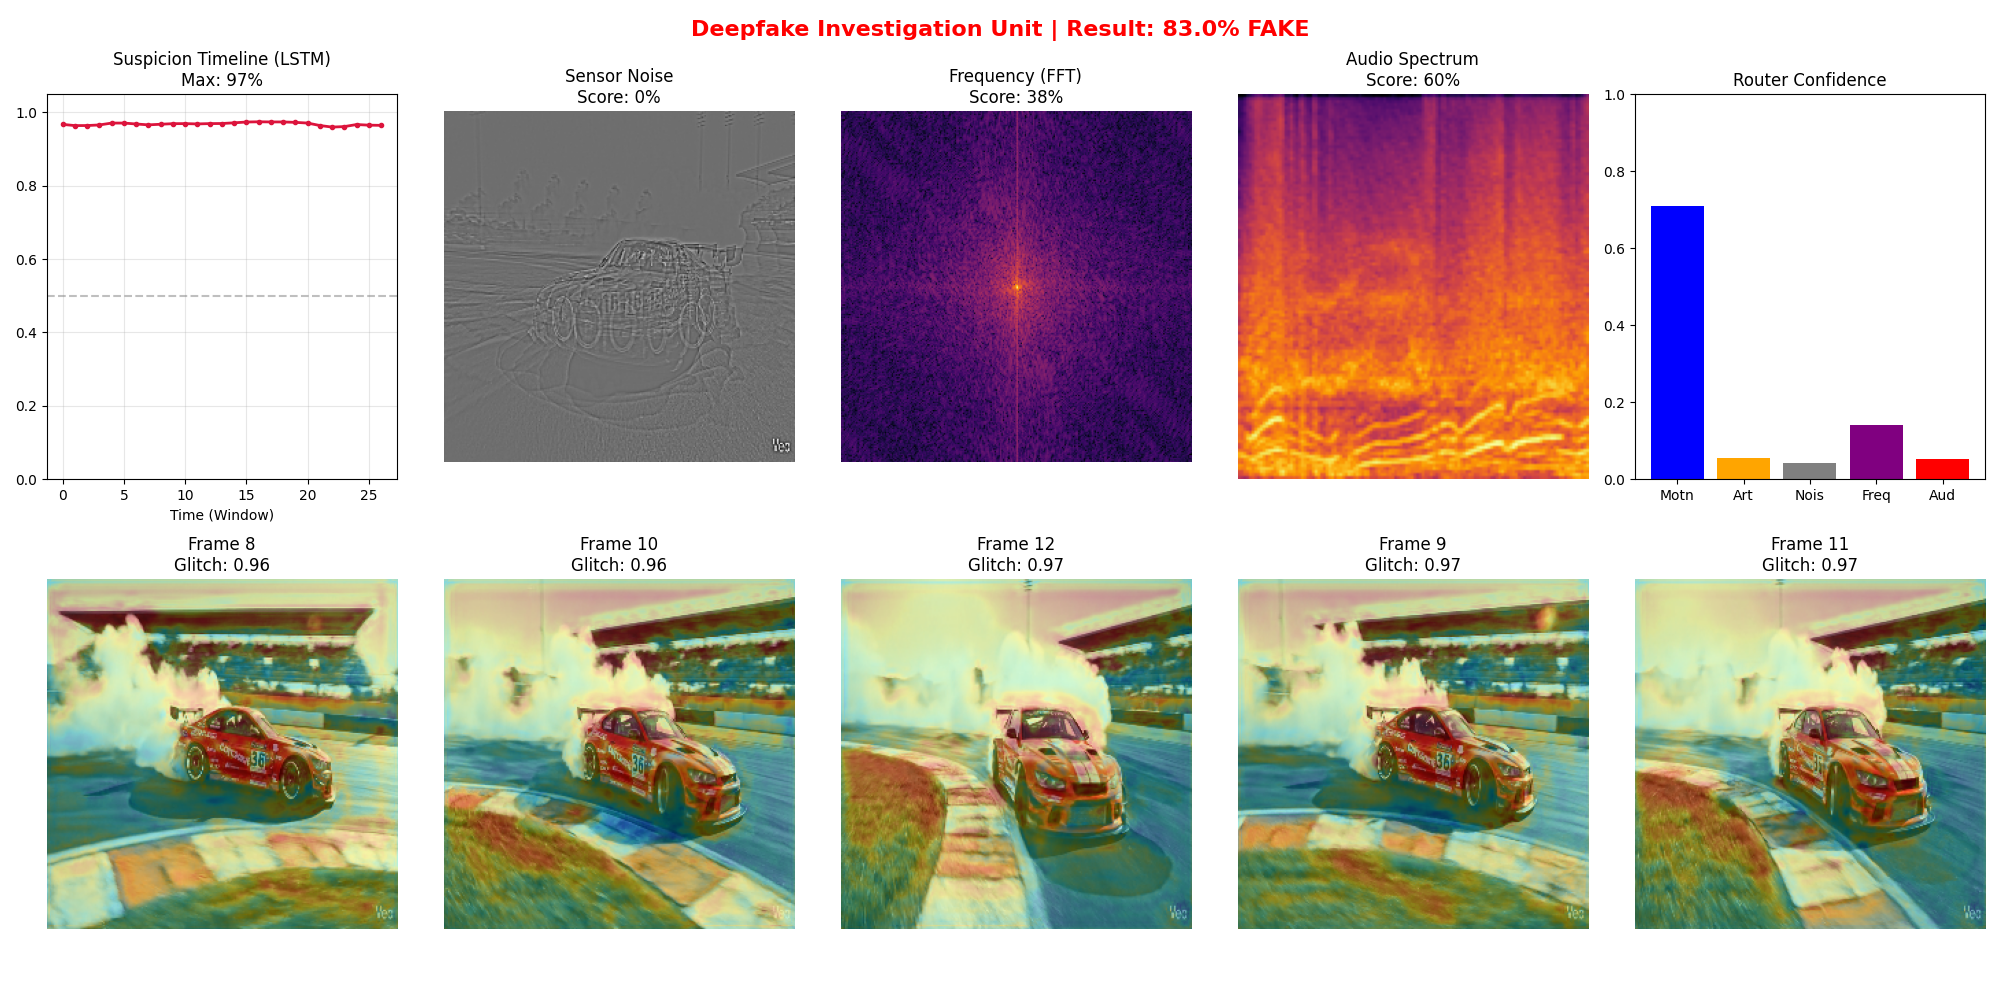

In [3]:
from IPython.display import Image, display

display(Image(filename="../investigation_report.png"))

# DONT rerun this cell